# Spektralne linije
Vežbovni seminar astronomije, 2024

Cilj ove radionice je da iskoristimo znanje o mehanizmima širenja spektralne linije i odredimo parametre linije na osnovu datih podataka. Da bismo to uradili, fitovaćemo naš model linije na podatke, uz pomoć Python bibloteke `scipy`. Ako ostane vremena, implementiraćemo i jednu od metoda koju ste videli na numeričkoj matematici kako bismo odredili ekvivalentnu širinu linije.

In [12]:
# Biblioteke

import numpy as np
import matplotlib.pyplot as plt

### Doplerovo širenje

Pretposavićemo da je Doplerovo širenje dominantan proces širenja linije, pa je profil linije dat izrazom

$$ \phi_\lambda = \frac{1}{\sqrt{\pi} \Delta\lambda_D} e ^{-(\frac{\lambda - \lambda_0}{\Delta\lambda_D})^2} $$

gde je $\Delta\lambda_D$ Doplerova širina, a $\lambda_0$ centralna talasna dužina linije.

Vaš prvi zadatak je da napišete funkciju koja za zadato $\Delta\lambda_D$, $\lambda_0$ i **niz talasnih dužina** računa profil $\phi_\lambda$. Nakon toga nacrtajte profil za $\Delta\lambda_D = 0.2 nm$ i $\lambda_0 = 500 nm$, kako biste proverili da li funkcija dobro radi. Za plotovanje uzmite opseg talasnih dužina od 499 do 501 nm.

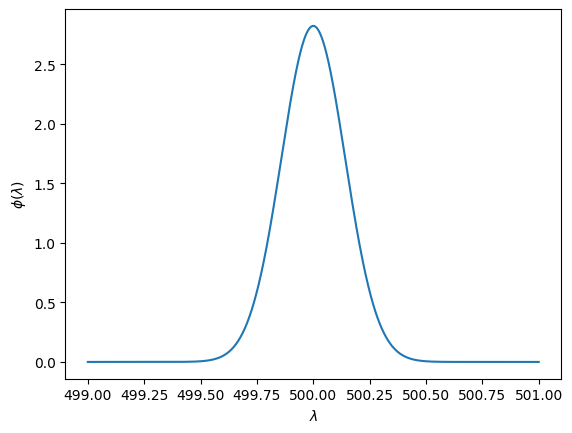

In [13]:
def gaus_prof(llambda, lambda_0, delta_lambda_d):
    eksponent = ((llambda - lambda_0)/delta_lambda_d)**2.0
    profil = 1./np.sqrt(np.pi) / delta_lambda_d * np.exp(-eksponent)
    return profil

llambda = np.linspace(499, 501, 1000)
profil = gaus_prof(llambda, 500, 0.2)
#profil2 = gaus_prof(llambda, 500, 0.4)
plt.plot(llambda, profil)
#plt.plot(llambda, profil2)
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\phi(\lambda)$')
plt.show()

### Apsorpciona linija

Gausov profil sada možemo da iskoristimo da nađemo izlazni intenzitet, odnosno njegovu raspodelu po talasnim dužinama (to je ono što možemo da merimo i što ćemo dobiti u podacima). Njega raučunamo na sledeći način:

$$ I = I_0 e^{-\tau \cdot \phi_\lambda} $$

gde je $\tau$ optička dubina, $I_0$ ulazni intenzitet zračenja, a $\phi_\lambda$ Gausov profil koji već znamo da izračunamo.

**Nadalje pretpostavljamo da je $I_0 = 1$.**

Napišite funkciju koja za zadato $\Delta\lambda_D$, $\lambda_0$ i $\tau$ i računa izlazni intenzitet $I$ (iskoristite i funkciju `gaus` koju ste napisali u prethodnom zadatku). Plotujte spektralnu liniju za vrednosti iz prethodnog zadatka, a za $\tau$ uzmite vrednost 1. Možete da se igrate sa vrednostima ovog parametra i vidite kako se menja oblik spektralne linije.

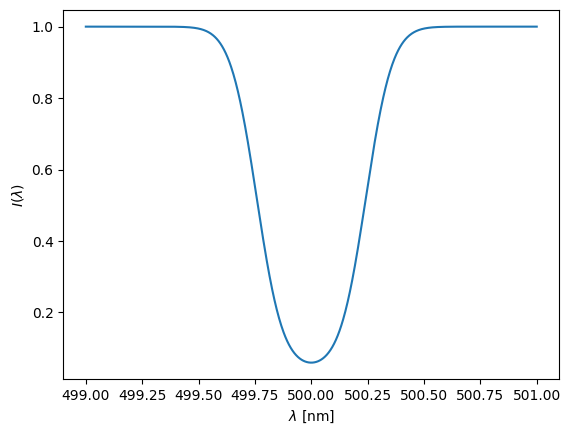

In [23]:
def spektar(llambda, lambda_0, delta_lambda_d, tau_u):
    phi_lambda = gaus_prof(llambda, lambda_0, delta_lambda_d)
    I_lambda = np.exp(- tau_u * phi_lambda)
    return I_lambda

intenzitet_guas = spektar(llambda, 500, 0.2, 3)
plt.plot(llambda, intenzitet_guas)
plt.xlabel('$\lambda$ [nm]')
plt.ylabel('$I(\lambda)$')
plt.show()

### Fitovanje

Sada kada imamo funkciju koja nam daje spektralnu liniju, odnosno **model**, možemo da je nafitujemo na podatke koji su nam dati i odredimo parametre linije ($\Delta\lambda_D$, $\lambda_0$ i $\tau$).

U fajlu *'spektralna_linija.txt'* nalaze se podaci za Na D spektralnu liniju. U prvoj koloni date su talasne dužine u nm, a u drugoj normalizovan intentitet.
Za početak učitajte ove podatke u numpy nizove i plotujte spektralnu liniju.

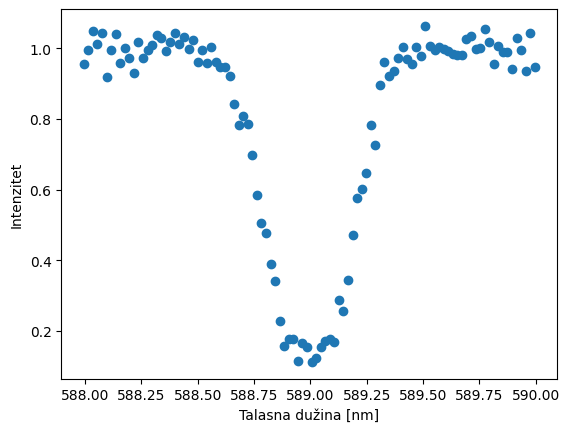

In [15]:
lam, I = np.loadtxt('spektralna_linija.txt', unpack=True)

plt.scatter(lam, I)
plt.xlabel('Talasna dužina [nm]')
plt.ylabel('Intenzitet')
plt.show()

Sada kada smo učitali podatke, možemo da fitujemo pomoću funkcije `curve_fit` iz paketa `scipy.optimize`.

Ispišite vrednosti svih dobijenih parametara, i na jednom grafiku plotujte učitane podatke i fit.

lam0 = 588.9944407584135 nm
delta_lambda_d = 0.19438528605536193 nm
tau = 0.7330290375403907 nm


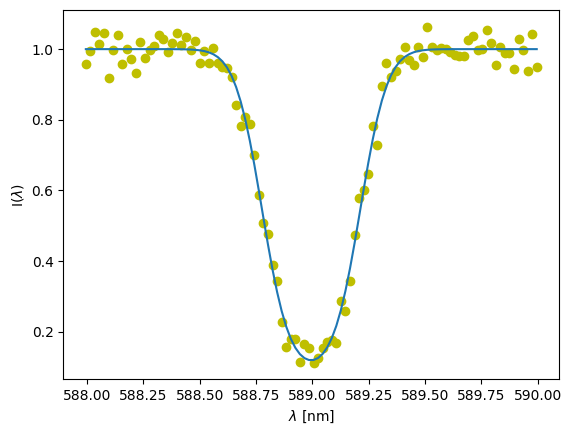

In [16]:
from scipy.optimize import curve_fit

parametri, cov_matrica = curve_fit(spektar, lam, I, p0=[589, 0.1, 1.0])
#print(*parametri)
# print(cov_matrica)
linija_fit = spektar(lam, *parametri)

# Parametri
lam0_fit, delta_lam_d_fit, tau_fit = parametri
print('lam0 =', lam0_fit, 'nm')
print('delta_lambda_d =', delta_lam_d_fit, 'nm')
print('tau =', tau_fit, 'nm')

plt.scatter(lam, I, label='podaci', c='y')
plt.plot(lam, linija_fit, label='fit')
plt.xlabel('$\lambda$ [nm]')
plt.ylabel('I($\lambda$)')
plt.show()



### Ekvivalentna širina

Za kraj ćemo odrediti ekvivalentnu širinu spektralne linije. Za to je potrebno da numerički rešimo integral, pa ćemo implementirati trapeznu metodu.

Ukoliko imamo poznatu vrednost funkcije u $N$ tačaka, integral po trapeznoj metodi aproksimiramo izrazom:

Napišite funkciju `trapezna_metoda` koja kao argumente prima nizove `x` i `y` koji predstavljaju vrednosti funkcije $f(x_i)$ u tačkama $x_i$ i vraća vrednost integrala.

In [17]:
def trapezna_metoda(x, y):
    dx = x[1] - x[0]
    integral = dx * (0.5*y[0] + 0.5*y[-1] + np.sum(y[1:-2]))
    return integral

Sada znamo da izračunamo integral, možemo da odredimo ekvivalentu širinu linije. Podsetite se šta ona predstavlja i kako se računa. Obratite pažnju na to da nam se u podacima nalazi normalizovan intenzitet, odnosno $F_{linija} / F_{kontinuum}$

Da biste proverili da li je integral dobro izračunat, uporedite vrednost koju vraća sa nekom od funkcija iz `scipy.integrate` paketa (npr. Simpsonova metoda)

In [18]:
sirina = trapezna_metoda(lam, 1-linija_fit)
print('Ekvivalentna sirina je: ', sirina)

from scipy.integrate import simpson
sirina_s = simpson(1-linija_fit, lam)
print('Scipy provera: ', sirina_s)

Ekvivalentna sirina je:  0.39576978268806823
Scipy provera:  0.395769782689573
